In [1]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 7.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/799.3 kB ? eta -:--:--
   --------------------------------------- 799.3/799.3 kB 18.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ------------------------------ --------- 3.7/4.9 MB 18.1 MB/s eta 0:00:01
   ---------------------------------------- 4.9/4.9 MB 15.4 MB/s eta 0:00:00

  Attempting uninstall: typing-extensions

    Found existing installation: typing_extensions 4.12.2

    Uninstalling typing_extensions-4.12.2:

   ----------------------------------------  0/25 [typing-extensions]
   ----------------------------------------  0/25 [typing-extensions]
   ----------------------------------------  0/25 [typing-extensions]
   ----------------------------------------  0/25 [typing-extensions]
   ----------------------------------------  0/25 [typ

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3fs 2025.3.2 requires fsspec==2025.3.2.*, but you have fsspec 2026.3.0 which is incompatible.


In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import gcsfs

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
plt.rcParams['figure.figsize'] = 12, 6

In [4]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


In [5]:
carbon_keywords = [
    "carbon",
    "co2",
    "cLand",
    "cSoil",
    "co2mass"
]

for keyword in carbon_keywords:
    matches = df[df["variable_id"].str.contains(keyword, case=False, na=False)]
    
    print(f"\n--- {keyword} ---")
    print(matches["variable_id"].unique()[:20])


--- carbon ---
[]

--- co2 ---
['co2mass' 'spco2' 'fgco2' 'dpco2' 'co23D' 'co2s' 'co2'
 'netAtmosLandCO2Flux' 'spco2abio' 'spco2nat' 'fgco2abio' 'fgco2nat'
 'dpco2nat' 'dpco2abio' 'fg14co2abio' 'fco2nat' 'fco2antt']

--- cLand ---
['cLand']

--- cSoil ---
['cSoil' 'cSoilLut' 'cSoilSlow' 'cSoilFast' 'cSoilMedium']

--- co2mass ---
['co2mass']


In [6]:
variables = ["cLand", "cSoil", "co2mass"]

In [7]:
df_carbon = df[
    df["variable_id"].isin(["cLand", "cSoil", "co2mass"])
]

df_carbon.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
686,CMIP,CNRM-CERFACS,CNRM-CM6-1,1pctCO2,r1i1p1f2,Amon,co2mass,gr,gs://cmip6/CMIP6/CMIP/CNRM-CERFACS/CNRM-CM6-1/...,NaN,20180626
1296,CMIP,NOAA-GFDL,GFDL-ESM4,esm-piControl,r1i1p1f1,Amon,co2mass,gn,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/esm-...,NaN,20180701
1465,CMIP,NOAA-GFDL,GFDL-ESM4,abrupt-4xCO2,r1i1p1f1,Emon,cLand,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/abru...,NaN,20180701
2116,CMIP,NOAA-GFDL,GFDL-ESM4,1pctCO2,r1i1p1f1,Emon,cLand,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/1pct...,NaN,20180701
2118,CMIP,NOAA-GFDL,GFDL-ESM4,1pctCO2,r1i1p1f1,Emon,cSoil,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/1pct...,NaN,20180701


In [8]:
df_carbon["experiment_id"].value_counts().head(20)

experiment_id
historical             395
ssp370                 181
hist-nat                72
1pctCO2                 70
piControl               40
abrupt-4xCO2            31
ssp245                  27
ssp126                  22
ssp585                  22
1pctCO2-bgc             21
1pctCO2-rad             17
land-hist                9
esm-hist                 8
ssp245-covid             7
ssp245-cov-strgreen      7
ssp245-cov-modgreen      6
ssp245-cov-fossil        6
ssp460                   5
ssp119                   5
esm-pi-CO2pulse          4
Name: count, dtype: int64

In [11]:
df_carbon = df_carbon[
    df_carbon["experiment_id"].isin([
        "historical",
        "ssp245",
        "ssp585"
    ])
]

df_carbon[[
    "variable_id",
    "experiment_id",
    "source_id",
    "table_id"
]].head(30)

,variable_id,experiment_id,source_id,table_id
2317,co2mass,ssp245,GFDL-CM4,Amon
2460,co2mass,ssp585,GFDL-CM4,Amon
6254,co2mass,historical,GFDL-CM4,Amon
15360,co2mass,ssp245,GFDL-ESM4,Amon
18976,co2mass,ssp585,GFDL-ESM4,Amon
22166,co2mass,historical,IPSL-CM6A-LR,Amon
22177,cSoil,historical,IPSL-CM6A-LR,Emon
22380,cSoil,historical,IPSL-CM6A-LR,Emon
22394,cSoil,historical,IPSL-CM6A-LR,Eyr
22461,cSoil,historical,IPSL-CM6A-LR,Eyr


In [12]:
df_co2 = df_carbon[
    df_carbon["variable_id"] == "co2mass"
]

df_co2[[
    "source_id",
    "experiment_id",
    "member_id",
    "table_id",
    "zstore"
]].head(20)

,source_id,experiment_id,member_id,table_id,zstore
2317,GFDL-CM4,ssp245,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM...
2460,GFDL-CM4,ssp585,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM...
6254,GFDL-CM4,historical,r1i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...
15360,GFDL-ESM4,ssp245,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ES...
18976,GFDL-ESM4,ssp585,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ES...
22166,IPSL-CM6A-LR,historical,r9i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...
23530,IPSL-CM6A-LR,historical,r6i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...
28063,IPSL-CM6A-LR,historical,r16i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...
29976,IPSL-CM6A-LR,historical,r28i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...
37683,CNRM-CM6-1,historical,r1i1p1f2,Amon,gs://cmip6/CMIP6/CMIP/CNRM-CERFACS/CNRM-CM6-1/...


In [14]:
df_co2_model = df_co2[
    df_co2["source_id"] == "GFDL-CM4"
]

df_co2_model[[
    "source_id",
    "experiment_id",
    "member_id",
    "table_id",
    "zstore"
]]

,source_id,experiment_id,member_id,table_id,zstore
2317,GFDL-CM4,ssp245,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM...
2460,GFDL-CM4,ssp585,r1i1p1f1,Amon,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM...
6254,GFDL-CM4,historical,r1i1p1f1,Amon,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...


In [15]:
co2_datasets = {}

for exp in ["historical", "ssp245", "ssp585"]:
    row = df_co2_model[df_co2_model["experiment_id"] == exp].iloc[0]
    zstore = row["zstore"]

    ds_exp = xr.open_zarr(
        gcsfs.GCSMap(zstore),
        consolidated=True
    )

    co2_datasets[exp] = ds_exp
    print(exp, ds_exp)

historical <xarray.Dataset> Size: 55kB
Dimensions:    (time: 1980, bnds: 2)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * bnds       (bnds) float64 16B 1.0 2.0
    time_bnds  (time, bnds) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Data variables:
    co2mass    (time) float32 8kB dask.array<chunksize=(990,), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36500.0
    comment:                <null ref>
    ...                     ...
    table_id:               Amon
    title:                  NOAA GFDL GFDL-CM4 model output prepared for CMIP...
    tracking_id:            hdl:21.14100/5be855d4-157c-4bd0-b895-09aadad0882d...
    variable_id:            co2mass
    variant_info:           N/A
    variant_label:          r1i1p1f1
ssp245 <xarray.Dataset>

In [16]:
co2_datasets["historical"]["co2mass"]

<xarray.DataArray 'co2mass' (time: 1980)> Size: 8kB
dask.array<open_dataset-co2mass, shape=(1980,), dtype=float32, chunksize=(990,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
Attributes:
    cell_methods:   area: time: mean
    long_name:      Total Atmospheric Mass of CO2
    original_name:  co2mass
    standard_name:  atmosphere_mass_of_carbon_dioxide
    units:          kg

In [17]:
co2_frames = []

for scenario, ds_exp in co2_datasets.items():

    co2 = ds_exp["co2mass"]

    yearly = co2.groupby("time.year").mean("time")

    temp_df = yearly.to_dataframe(name="co2mass").reset_index()

    temp_df["scenario"] = scenario

    co2_frames.append(temp_df)

co2_df = pd.concat(co2_frames, ignore_index=True)

co2_df = co2_df[[
    "year",
    "scenario",
    "co2mass"
]]

co2_df.head()

,year,scenario,co2mass
0,1850,historical,2.214735e+15
1,1851,historical,2.215836e+15
2,1852,historical,2.216960e+15
3,1853,historical,2.217980e+15
4,1854,historical,2.218872e+15


In [19]:
co2_df.to_csv(
    "../data/processed/co2_timeseries.csv",
    index=False
)

In [20]:
df_cland = df_carbon[
    df_carbon["variable_id"] == "cLand"
]

df_cland[[
    "source_id",
    "experiment_id",
    "member_id",
    "table_id"
]].head(20)

,source_id,experiment_id,member_id,table_id
244666,GFDL-ESM4,historical,r1i1p1f1,Emon


In [21]:
row = df_cland.iloc[0]
zstore = row["zstore"]

ds_cland = xr.open_zarr(
    gcsfs.GCSMap(zstore),
    consolidated=True
)

ds_cland

<xarray.Dataset> Size: 411MB
Dimensions:    (time: 1980, lat: 180, lon: 288, bnds: 2)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * bnds       (bnds) float64 16B 1.0 2.0
    lat_bnds   (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    time_bnds  (time, bnds) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Data variables:
    cLand      (time, lat, lon) float32 411MB dask.array<chunksize=(703, 180, 288), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36500.0
    comment:                <null ref>
    ...                     ...
    table_id:               Emon
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/210cd3f1-ec15-416d-a7b6-7657b5405c59...
    variable_id:            cLand
    variant_info:           N/A
    variant_label:          r1i1p1f1

In [22]:
ds_cland["cLand"]

<xarray.DataArray 'cLand' (time: 1980, lat: 180, lon: 288)> Size: 411MB
dask.array<open_dataset-cLand, shape=(1980, 180, 288), dtype=float32, chunksize=(703, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
Attributes:
    cell_measures:    area: areacella
    cell_methods:     area: mean where land time: mean
    comment:          land_area = areacella * sftlf * 0.01
    interp_method:    conserve_order1
    long_name:        Total Carbon in All Terrestrial Carbon Pools
    ocean_fillvalue:  0.0
    original_name:    cLand
    standard_name:    mass_content_of_carbon_in_vegetation_and_litter_and_soi...
    units:            kg m-2

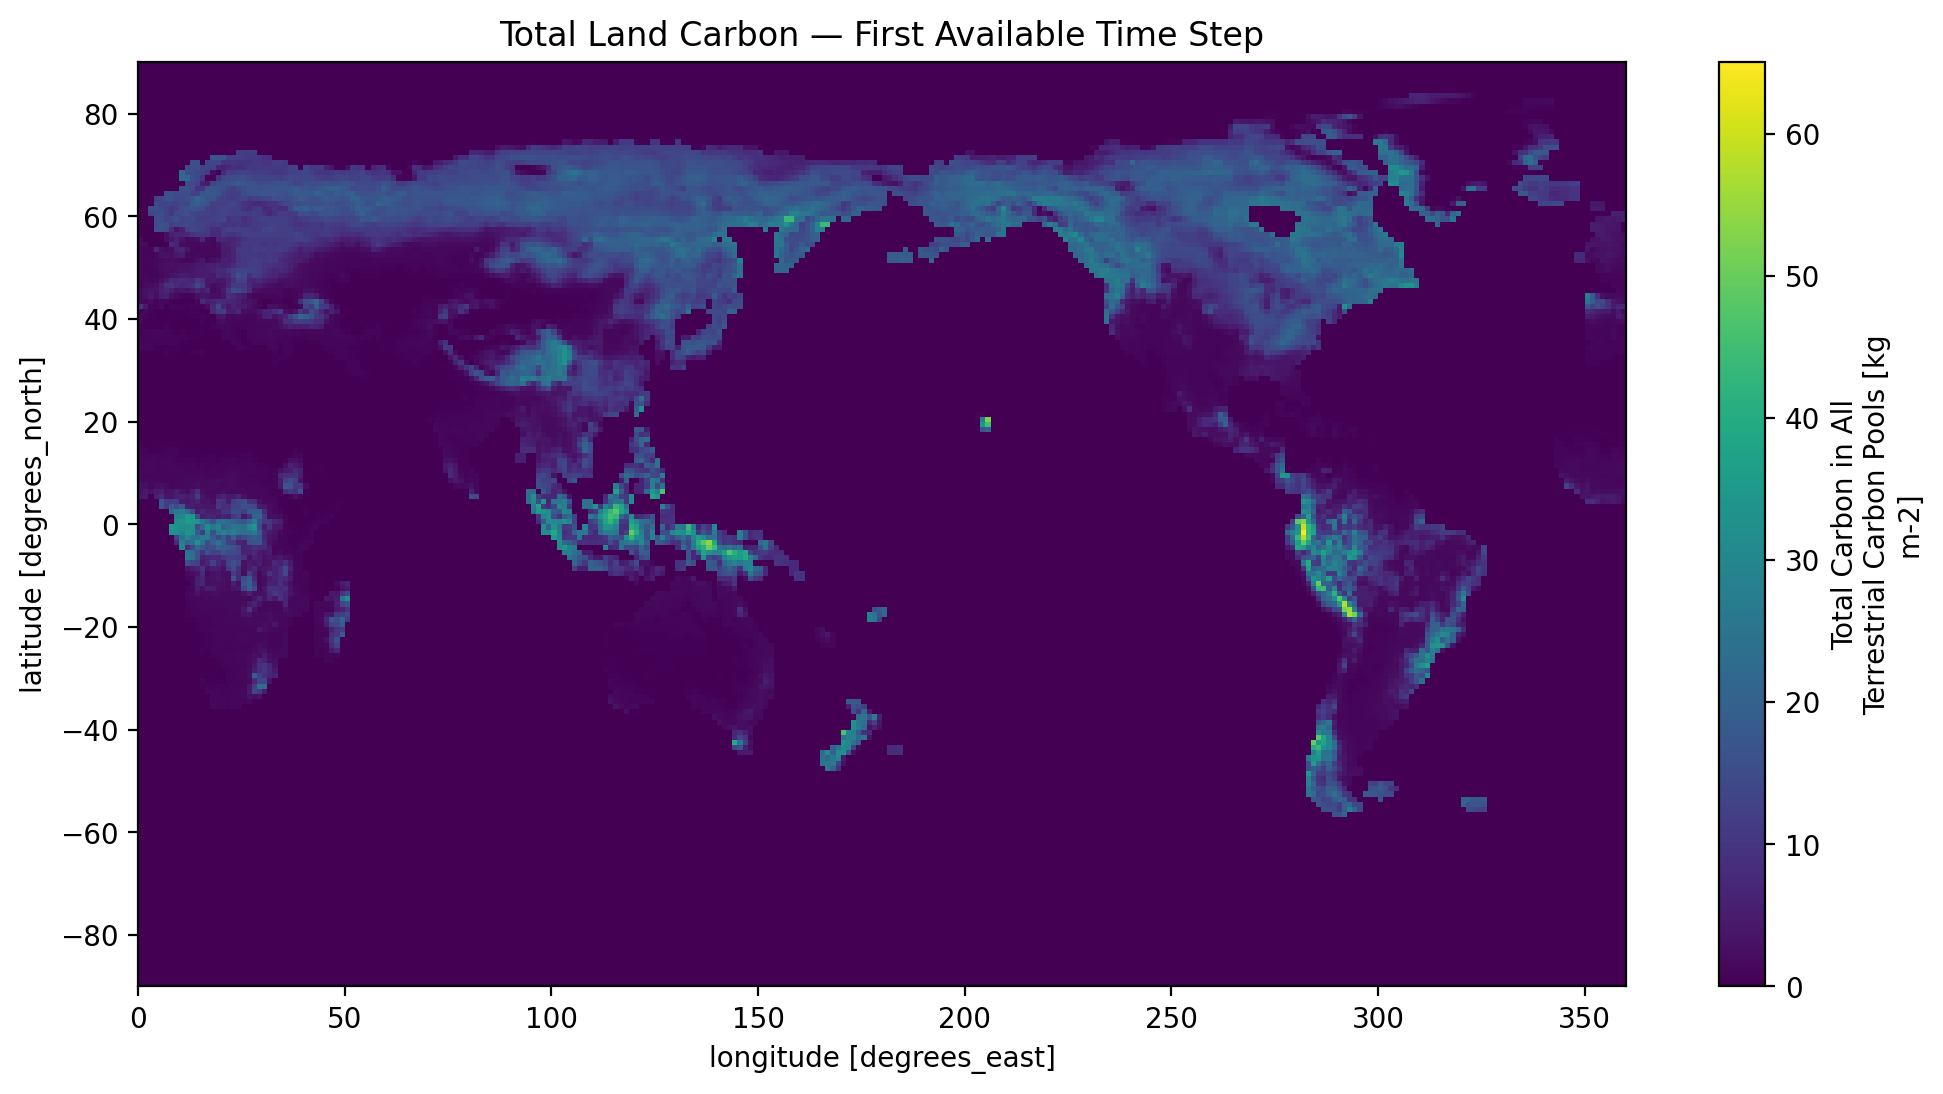

In [23]:
ds_cland["cLand"].isel(time=0).plot()
plt.title("Total Land Carbon — First Available Time Step")
plt.show()

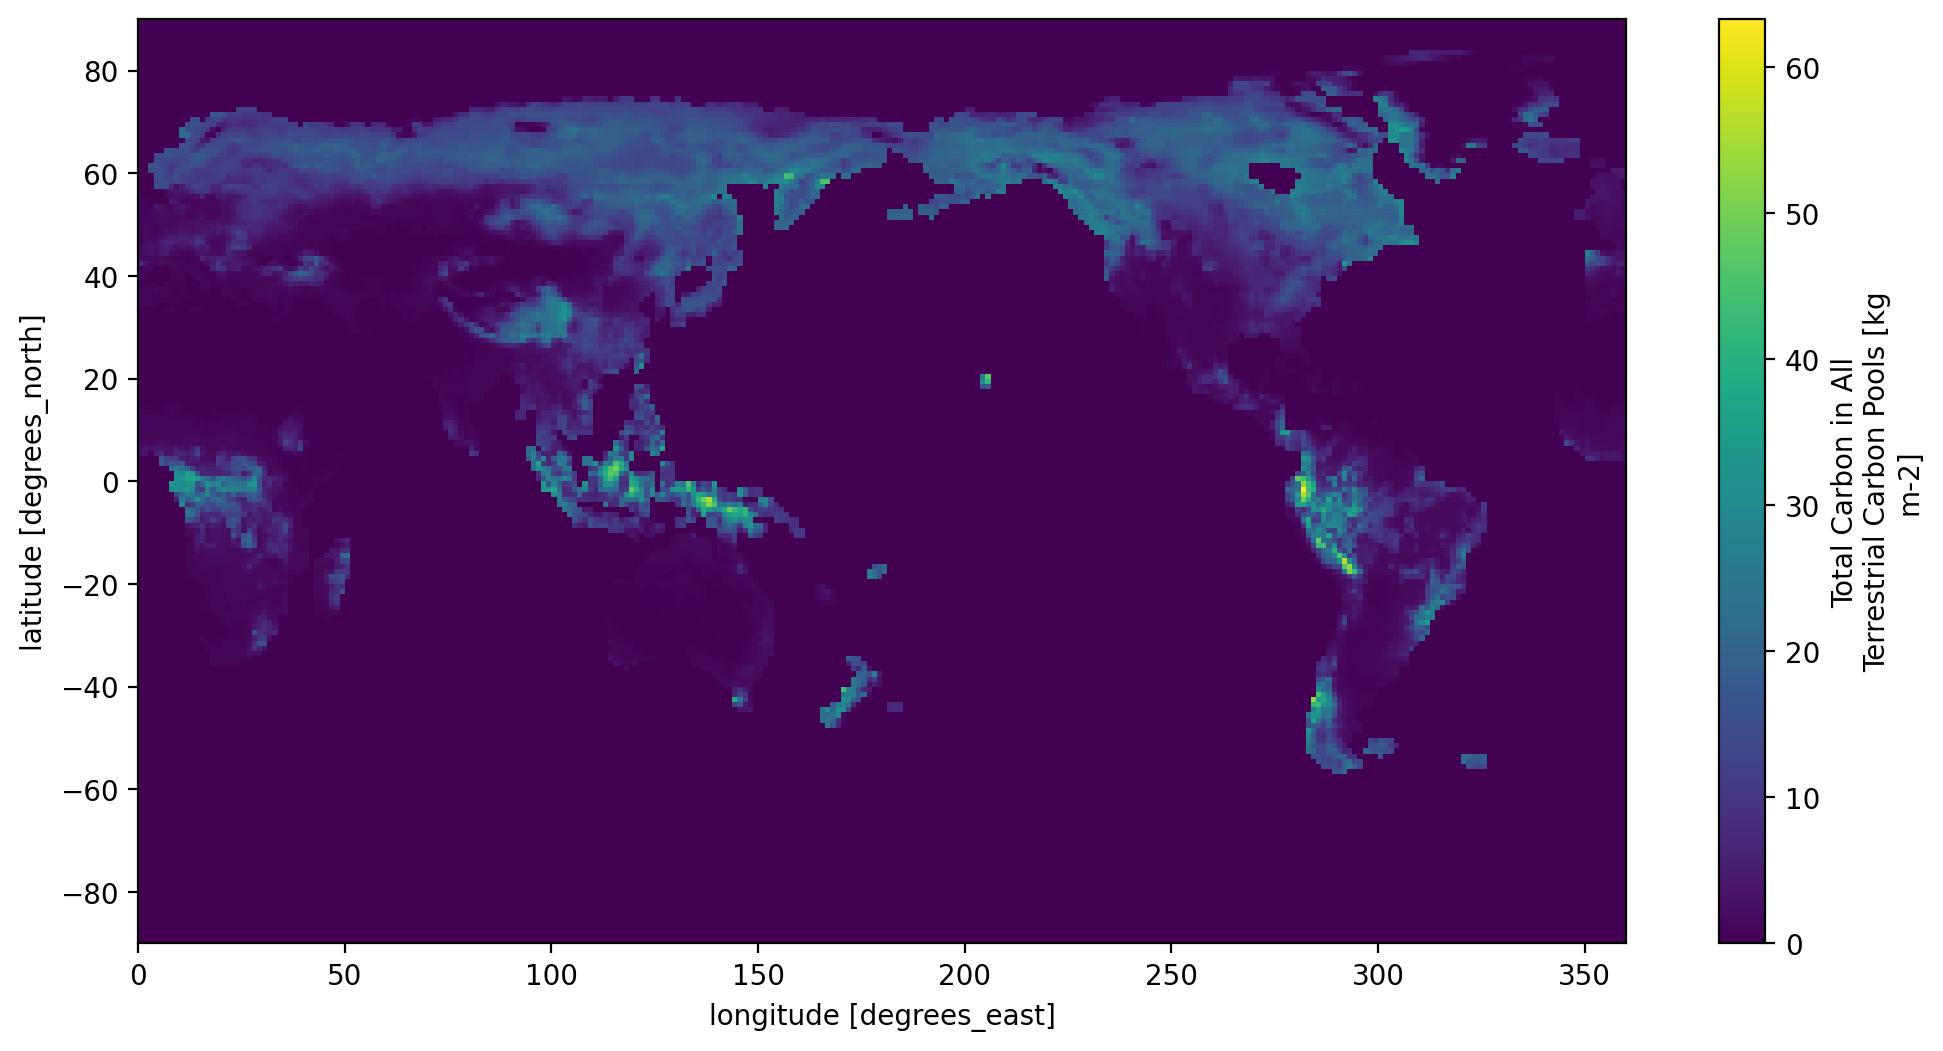

In [21]:
ds_cland["cLand"].mean(dim="time").plot()

In [24]:
cland_mean = ds_cland["cLand"].mean(dim="time")

cland_df = cland_mean.to_dataframe(name="cLand").reset_index()

cland_df = cland_df.rename(columns={
    "lat": "latitude",
    "lon": "longitude"
})

cland_df = cland_df.dropna()

cland_df.head()

,latitude,longitude,cLand
0,-89.5,0.625,0.001302
1,-89.5,1.875,0.001302
2,-89.5,3.125,0.001302
3,-89.5,4.375,0.001302
4,-89.5,5.625,0.001302


In [25]:
cland_df.to_csv(
    "../data/processed/cland_mean.csv",
    index=False
)

In [26]:
"""
Extract CMIP6 variables: tas (temperature) and fgco2 (ocean CO2 flux).
Uses zarr_format=2 to work with zarr 3.x against CMIP6 zarr-v2 stores.

Outputs:
  data/processed/tas_timeseries.csv   — global mean near-surface temperature (°C)
  data/processed/fgco2_timeseries.csv — global mean ocean CO2 flux (g m-2 yr-1)
"""

import pandas as pd
import xarray as xr
import gcsfs
import numpy as np

fs = gcsfs.GCSFileSystem(token="anon")

def open_zarr(zstore):
    return xr.open_zarr(
        fs.get_mapper(zstore),
        consolidated=True,
        zarr_format=2
    )

def weighted_spatial_mean(da):
    """Cosine-latitude weighted global mean. Handles lat or latitude coord name."""
    lat_name = "lat" if "lat" in da.coords else "latitude"
    lon_name = "lon" if "lon" in da.coords else "longitude"
    w = np.cos(np.deg2rad(da[lat_name]))
    w.name = "weights"
    return da.weighted(w).mean((lat_name, lon_name))

def to_annual_df(da, value_col):
    yearly = da.groupby("time.year").mean("time")
    return yearly.to_dataframe(name=value_col).reset_index()[["year", value_col]]

# ── Hardcoded store paths (from catalog lookup) ────────────────────────────────
TAS_STORES = {
    "historical": "gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/r1i1p1f1/Amon/tas/gr1/v20180701/",
    "ssp245":     "gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM4/ssp245/r1i1p1f1/Amon/tas/gr1/v20180701/",
    "ssp585":     "gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM4/ssp585/r1i1p1f1/Amon/tas/gr1/v20180701/",
}

# GFDL-ESM4: esm-hist covers 1850-2014 (same period as CMIP historical)
FGCO2_STORES = {
    "historical": "gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/esm-hist/r1i1p1f1/Omon/fgco2/gr/v20180701/",
    "ssp245":     "gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ESM4/ssp245/r1i1p1f1/Omon/fgco2/gr/v20180701/",
    "ssp585":     "gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ESM4/ssp585/r1i1p1f1/Omon/fgco2/gr/v20180701/",
}

# ── 1. tas ─────────────────────────────────────────────────────────────────────
print("=== Extracting tas (temperature) ===", flush=True)
tas_frames = []

for scenario, zstore in TAS_STORES.items():
    print(f"  {scenario}...", flush=True)
    ds = open_zarr(zstore)
    gm = weighted_spatial_mean(ds["tas"])
    df = to_annual_df(gm, "tas")
    df["scenario"] = scenario
    df["tas"] -= 273.15  # K → °C
    tas_frames.append(df)
    print(f"    {df['year'].min()}–{df['year'].max()}, {len(df)} rows, "
          f"mean={df['tas'].mean():.2f}°C", flush=True)

tas_out = pd.concat(tas_frames, ignore_index=True)
tas_out.to_csv("../data/processed/tas_timeseries.csv", index=False)
print(f"Saved tas_timeseries.csv ({len(tas_out)} rows)\n", flush=True)

# ── 2. fgco2 ──────────────────────────────────────────────────────────────────
print("=== Extracting fgco2 (ocean CO2 flux) ===", flush=True)
fgco2_frames = []

for scenario, zstore in FGCO2_STORES.items():
    print(f"  {scenario}...", flush=True)
    ds = open_zarr(zstore)
    da = ds["fgco2"]
    print(f"    coords: {list(da.coords)}", flush=True)
    gm = weighted_spatial_mean(da)
    df = to_annual_df(gm, "fgco2")
    df["scenario"] = scenario
    df["fgco2"] *= 1000 * 86400 * 365  # kg m-2 s-1 → g m-2 yr-1
    fgco2_frames.append(df)
    print(f"    {df['year'].min()}–{df['year'].max()}, {len(df)} rows, "
          f"mean={df['fgco2'].mean():.4f} g/m²/yr", flush=True)

fgco2_out = pd.concat(fgco2_frames, ignore_index=True)
fgco2_out.to_csv("../data/processed/fgco2_timeseries.csv", index=False)
print(f"Saved fgco2_timeseries.csv ({len(fgco2_out)} rows)\n", flush=True)

print("Done!", flush=True)


=== Extracting tas (temperature) ===
  historical...
    1850–2014, 165 rows, mean=12.88°C
  ssp245...
    2015–2100, 86 rows, mean=14.91°C
  ssp585...
    2015–2100, 86 rows, mean=15.69°C
Saved tas_timeseries.csv (337 rows)

=== Extracting fgco2 (ocean CO2 flux) ===
  historical...
    coords: ['lat', 'lon', 'time']
    1850–2014, 165 rows, mean=3.1749 g/m²/yr
  ssp245...
    coords: ['lat', 'lon', 'time']
    2015–2100, 86 rows, mean=9.1080 g/m²/yr
  ssp585...
    coords: ['lat', 'lon', 'time']
    2015–2100, 86 rows, mean=14.3164 g/m²/yr
Saved fgco2_timeseries.csv (337 rows)

Done!
